In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier

data = pd.read_csv('new\\processed_fpt.csv', parse_dates=['time'])
data.head()

,time,open,high,low,close,volume,Symbol,OBV,RSI6,RSI12,...,outMACD,outMACDSignal,outMACDHist,WILLR,TSF10,TSF20,TRIX,BBANDSMIDDLE,BBANDSUPPER,BBANDSLOWER
0,2018-01-01,17560.0,18330.0,17530.0,18330.0,5022160.0,FPT,0.0,64.230769,55.12605,...,0.000000,0.000000,0.000000,25.842697,18935.777778,18383.912281,0.000000,18498.571429,19030.133368,17967.009489
1,2018-01-02,17560.0,18330.0,17530.0,18330.0,5022160.0,FPT,0.0,64.230769,55.12605,...,0.000000,0.000000,0.000000,25.842697,18935.777778,18383.912281,0.000000,18498.571429,19030.133368,17967.009489
2,2018-01-03,18540.0,18600.0,18240.0,18330.0,2829930.0,FPT,0.0,64.230769,55.12605,...,0.000000,0.000000,0.000000,25.842697,18935.777778,18383.912281,0.000000,18498.571429,19030.133368,17967.009489
3,2018-01-04,18390.0,18700.0,18360.0,18700.0,2784800.0,FPT,2784800.0,64.230769,55.12605,...,29.515670,5.903134,23.612536,25.842697,18935.777778,18383.912281,0.003942,18498.571429,19030.133368,17967.009489
4,2018-01-05,18700.0,18730.0,18360.0,18390.0,2851450.0,FPT,-66650.0,64.230769,55.12605,...,27.574776,10.237462,17.337314,25.842697,18935.777778,18383.912281,0.007046,18498.571429,19030.133368,17967.009489


In [2]:
# Pivot dữ liệu: index = time, cột là các chỉ báo với tiền tố là tên Symbol
pivot_data = data.pivot(index='time', columns='Symbol')
pivot_data.columns = ['{}_{}'.format(sym, feat) for feat, sym in pivot_data.columns]
pivot_data.reset_index(inplace=True)
pivot_data.head()

,time,FPT_open,VN30_open,VNINDEX_open,FPT_high,VN30_high,VNINDEX_high,FPT_low,VN30_low,VNINDEX_low,...,VNINDEX_TRIX,FPT_BBANDSMIDDLE,VN30_BBANDSMIDDLE,VNINDEX_BBANDSMIDDLE,FPT_BBANDSUPPER,VN30_BBANDSUPPER,VNINDEX_BBANDSUPPER,FPT_BBANDSLOWER,VN30_BBANDSLOWER,VNINDEX_BBANDSLOWER
0,2018-01-01,17560.0,977200.0,986050.0,18330.0,992720.0,996180.0,17530.0,975490.0,984240.0,...,-0.013286,18498.571429,190667.619048,1.304739e+06,19030.133368,5.582617e+05,1.450231e+06,17967.009489,-176926.500583,1.159247e+06
1,2018-01-02,17560.0,977200.0,986050.0,18330.0,992720.0,996180.0,17530.0,975490.0,984240.0,...,-0.089761,18498.571429,230916.190476,1.290412e+06,19030.133368,7.374797e+05,1.488869e+06,17967.009489,-275647.303047,1.091955e+06
2,2018-01-03,18540.0,996230.0,999860.0,18600.0,1011840.0,1010210.0,18240.0,992720.0,995770.0,...,-0.183449,18498.571429,271728.571429,1.276475e+06,19030.133368,8.783243e+05,1.510510e+06,17967.009489,-334867.191961,1.042440e+06
3,2018-01-04,18390.0,1007600.0,1009370.0,18700.0,1014170.0,1019750.0,18360.0,1004660.0,1005670.0,...,-0.282540,18498.571429,313111.904762,1.263643e+06,19030.133368,9.970684e+05,1.522930e+06,17967.009489,-370844.628576,1.004356e+06
4,2018-01-05,18700.0,1014420.0,1020340.0,18730.0,1014420.0,1020600.0,18360.0,1005100.0,1010650.0,...,-0.381965,18498.571429,354170.476190,1.250072e+06,19030.133368,1.096866e+06,1.530829e+06,17967.009489,-388524.792820,9.693148e+05


In [3]:
# Danh sách các chỉ báo kỹ thuật (theo paper)
full_features = [
    'close', 'OBV', 'volume', 'RSI6', 'RSI12', 'SMA3', 'EMA6',
    'EMA12', 'ATR14', 'MFI14', 'ADX14', 'ADX20', 'MOM1', 'MOM3',
    'CCI12', 'CCI20', 'ROCR3', 'ROCR12', 'outMACD', 'outMACDSignal',
    'outMACDHist', 'WILLR', 'TSF10', 'TSF20', 'TRIX', 
    'BBANDSUPPER', 'BBANDSMIDDLE', 'BBANDSLOWER'
]

# Hàm lấy các cột đặc trưng theo mã
def get_features(df, symbol):
    cols = [f"{symbol}_{feat}" for feat in full_features]
    return df[cols]

In [4]:
# Xây dựng ma trận đặc trưng theo thứ tự: FPT, VN30, VNINDEX
X_fpt = get_features(pivot_data, 'FPT')
X_vn30 = get_features(pivot_data, 'VN30')
X_vnindex = get_features(pivot_data, 'VNINDEX')
X = pd.concat([X_fpt, X_vn30, X_vnindex], axis=1)
print("Kích thước ma trận X:", X.shape)

Kích thước ma trận X: (2588, 84)


1 day prediction

In [5]:
prices = pivot_data['FPT_close']
Y = np.where(prices.shift(-1) > prices, 1, -1)
X = X.iloc[:-1, :]
Y = Y[:-1]

3 days prediction

In [6]:
# # Ví dụ tính SMA 3 ngày: dùng giá FPT_Adj Close
# def SMA(series, window=3):
#     return series.rolling(window=window).mean()

# sma = SMA(prices, window=3)
# # Dự đoán xu hướng trung bình 3 ngày: so sánh SMA(t+3) và SMA(t)
# Y = np.where(sma.shift(-3) > sma, 1, -1)
# # Loại bỏ các dòng có giá trị NaN
# X = X.iloc[:-3, :]
# Y = Y[:-3]

In [7]:
print("Kích thước vector Y:", Y.shape)

Kích thước vector Y: (2587,)


In [8]:
X.head()

,FPT_close,FPT_OBV,FPT_volume,FPT_RSI6,FPT_RSI12,FPT_SMA3,FPT_EMA6,FPT_EMA12,FPT_ATR14,FPT_MFI14,...,VNINDEX_outMACD,VNINDEX_outMACDSignal,VNINDEX_outMACDHist,VNINDEX_WILLR,VNINDEX_TSF10,VNINDEX_TSF20,VNINDEX_TRIX,VNINDEX_BBANDSUPPER,VNINDEX_BBANDSMIDDLE,VNINDEX_BBANDSLOWER
0,18330.0,0.0,5022160.0,64.230769,55.12605,18330.000000,18330.000000,18330.000000,800.000000,36.822497,...,-21306.221594,-1569.995288,-19736.226306,96.754946,1.201872e+06,1.280968e+06,-0.013286,1.450231e+06,1.304739e+06,1.159247e+06
1,18330.0,0.0,5022160.0,64.230769,55.12605,18330.000000,18330.000000,18330.000000,800.000000,36.822497,...,-42382.299197,-9732.456070,-32649.843127,96.754946,1.086922e+06,1.218305e+06,-0.089761,1.488869e+06,1.290412e+06,1.091955e+06
2,18330.0,0.0,2829930.0,64.230769,55.12605,18330.000000,18330.000000,18330.000000,768.571429,36.822497,...,-57622.162855,-19310.397427,-38311.765428,93.968647,9.997300e+05,1.161345e+06,-0.183449,1.510510e+06,1.276475e+06,1.042440e+06
3,18700.0,2784800.0,2784800.0,64.230769,55.12605,18453.333333,18435.714286,18386.923077,740.102041,36.822497,...,-67782.373267,-29004.792595,-38777.580672,90.005910,9.402980e+05,1.112652e+06,-0.282540,1.522930e+06,1.263643e+06,1.004356e+06
4,18390.0,-66650.0,2851450.0,64.230769,55.12605,18473.333333,18422.653061,18387.396450,713.666181,36.822497,...,-75536.585147,-38311.151105,-37225.434042,92.004165,8.992153e+05,1.067576e+06,-0.381965,1.530829e+06,1.250072e+06,9.693148e+05


In [9]:
Y[:5]

array([-1, -1,  1, -1,  1])

In [10]:
window_train = 800
window_test = 30
step = 5
n = len(X)
n_splits = (n - window_train - window_test) // step + 1
print("Số cửa sổ rolling:", n_splits)

Số cửa sổ rolling: 352


In [11]:
# accuracies = []
# best_params_list = []

# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': [0.001, 0.01, 0.1, 1]
# }

# for i in range(n_splits):
#     start = i * step
#     end_train = start + window_train
#     end_test = end_train + window_test
#     X_train = X.iloc[start:end_train, :].values
#     Y_train = Y[start:end_train]
#     X_test = X.iloc[end_train:end_test, :].values
#     Y_test = Y[end_train:end_test]
    
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     svc = SVC(kernel='rbf')
#     cv = StratifiedKFold(n_splits=5)
#     grid = GridSearchCV(svc, param_grid, cv=cv, scoring='accuracy')
#     grid.fit(X_train_scaled, Y_train)
#     best_model = grid.best_estimator_
    
#     Y_pred = best_model.predict(X_test_scaled)
#     acc = accuracy_score(Y_test, Y_pred)
#     accuracies.append(acc)
#     best_params_list.append(grid.best_params_)
#     print(f"Cửa sổ {i+1}: Độ chính xác = {acc:.4f}, Tham số tốt nhất = {grid.best_params_}")

In [12]:
accuracies = []
best_params_list = []

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

for i in range(n_splits):
    start = i * step
    end_train = start + window_train
    end_test = end_train + window_test
    X_train = X.iloc[start:end_train, :].values
    Y_train = Y[start:end_train]
    X_test = X.iloc[end_train:end_test, :].values
    Y_test = Y[end_train:end_test]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ---------------- Feature Selection ----------------
    etc = ExtraTreesClassifier(n_estimators=100, random_state=42)
    etc.fit(X_train_scaled, Y_train)
    
    importances = etc.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    k = int(np.ceil(0.3 * X_train_scaled.shape[1]))
    selected_indices = indices[:k]
    
    X_train_fs = X_train_scaled[:, selected_indices]
    X_test_fs = X_test_scaled[:, selected_indices]
    
    svc = SVC(kernel='rbf')
    cv = StratifiedKFold(n_splits=5)
    grid = GridSearchCV(svc, param_grid, cv=cv, scoring='accuracy')
    grid.fit(X_train_fs, Y_train)
    best_model = grid.best_estimator_
    
    Y_pred = best_model.predict(X_test_fs)
    acc = accuracy_score(Y_test, Y_pred)
    accuracies.append(acc)
    best_params_list.append(grid.best_params_)
    
    print(f"Cửa sổ {i+1}: Độ chính xác = {acc:.4f}, Tham số tốt nhất = {grid.best_params_}, Số feature đã chọn = {k}")


Cửa sổ 1: Độ chính xác = 0.5333, Tham số tốt nhất = {'C': 100, 'gamma': 0.001}, Số feature đã chọn = 26
Cửa sổ 2: Độ chính xác = 0.7000, Tham số tốt nhất = {'C': 100, 'gamma': 0.01}, Số feature đã chọn = 26
Cửa sổ 3: Độ chính xác = 0.5667, Tham số tốt nhất = {'C': 1, 'gamma': 0.1}, Số feature đã chọn = 26
Cửa sổ 4: Độ chính xác = 0.4333, Tham số tốt nhất = {'C': 1, 'gamma': 0.1}, Số feature đã chọn = 26
Cửa sổ 5: Độ chính xác = 0.4333, Tham số tốt nhất = {'C': 1, 'gamma': 0.01}, Số feature đã chọn = 26
Cửa sổ 6: Độ chính xác = 0.7333, Tham số tốt nhất = {'C': 10, 'gamma': 0.01}, Số feature đã chọn = 26
Cửa sổ 7: Độ chính xác = 0.6000, Tham số tốt nhất = {'C': 10, 'gamma': 0.001}, Số feature đã chọn = 26
Cửa sổ 8: Độ chính xác = 0.7667, Tham số tốt nhất = {'C': 1, 'gamma': 0.01}, Số feature đã chọn = 26
Cửa sổ 9: Độ chính xác = 0.6667, Tham số tốt nhất = {'C': 1, 'gamma': 0.01}, Số feature đã chọn = 26
Cửa sổ 10: Độ chính xác = 0.6333, Tham số tốt nhất = {'C': 100, 'gamma': 0.001}, Số f

Độ chính xác trung bình trên tập test: 0.5025568181818182


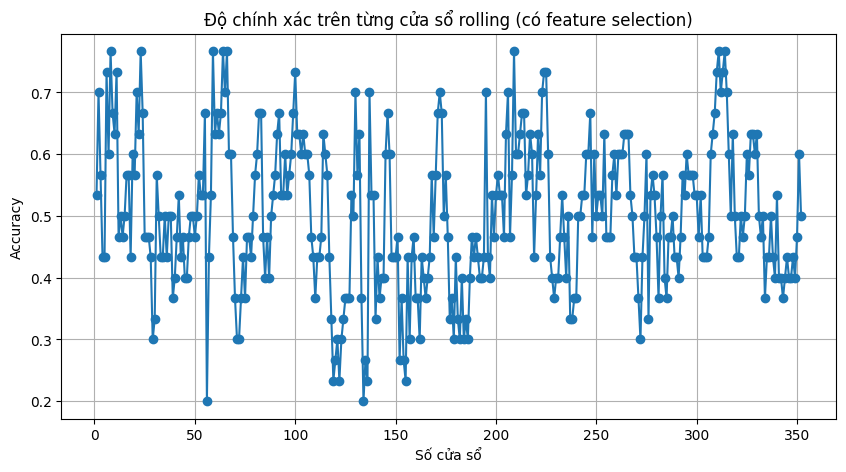

In [13]:
avg_accuracy = np.mean(accuracies)
print("Độ chính xác trung bình trên tập test:", avg_accuracy)

# Vẽ đồ thị độ chính xác theo từng cửa sổ rolling
plt.figure(figsize=(10,5))
plt.plot(range(1, n_splits+1), accuracies, marker='o')
plt.title("Độ chính xác trên từng cửa sổ rolling (có feature selection)")
plt.xlabel("Số cửa sổ")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()